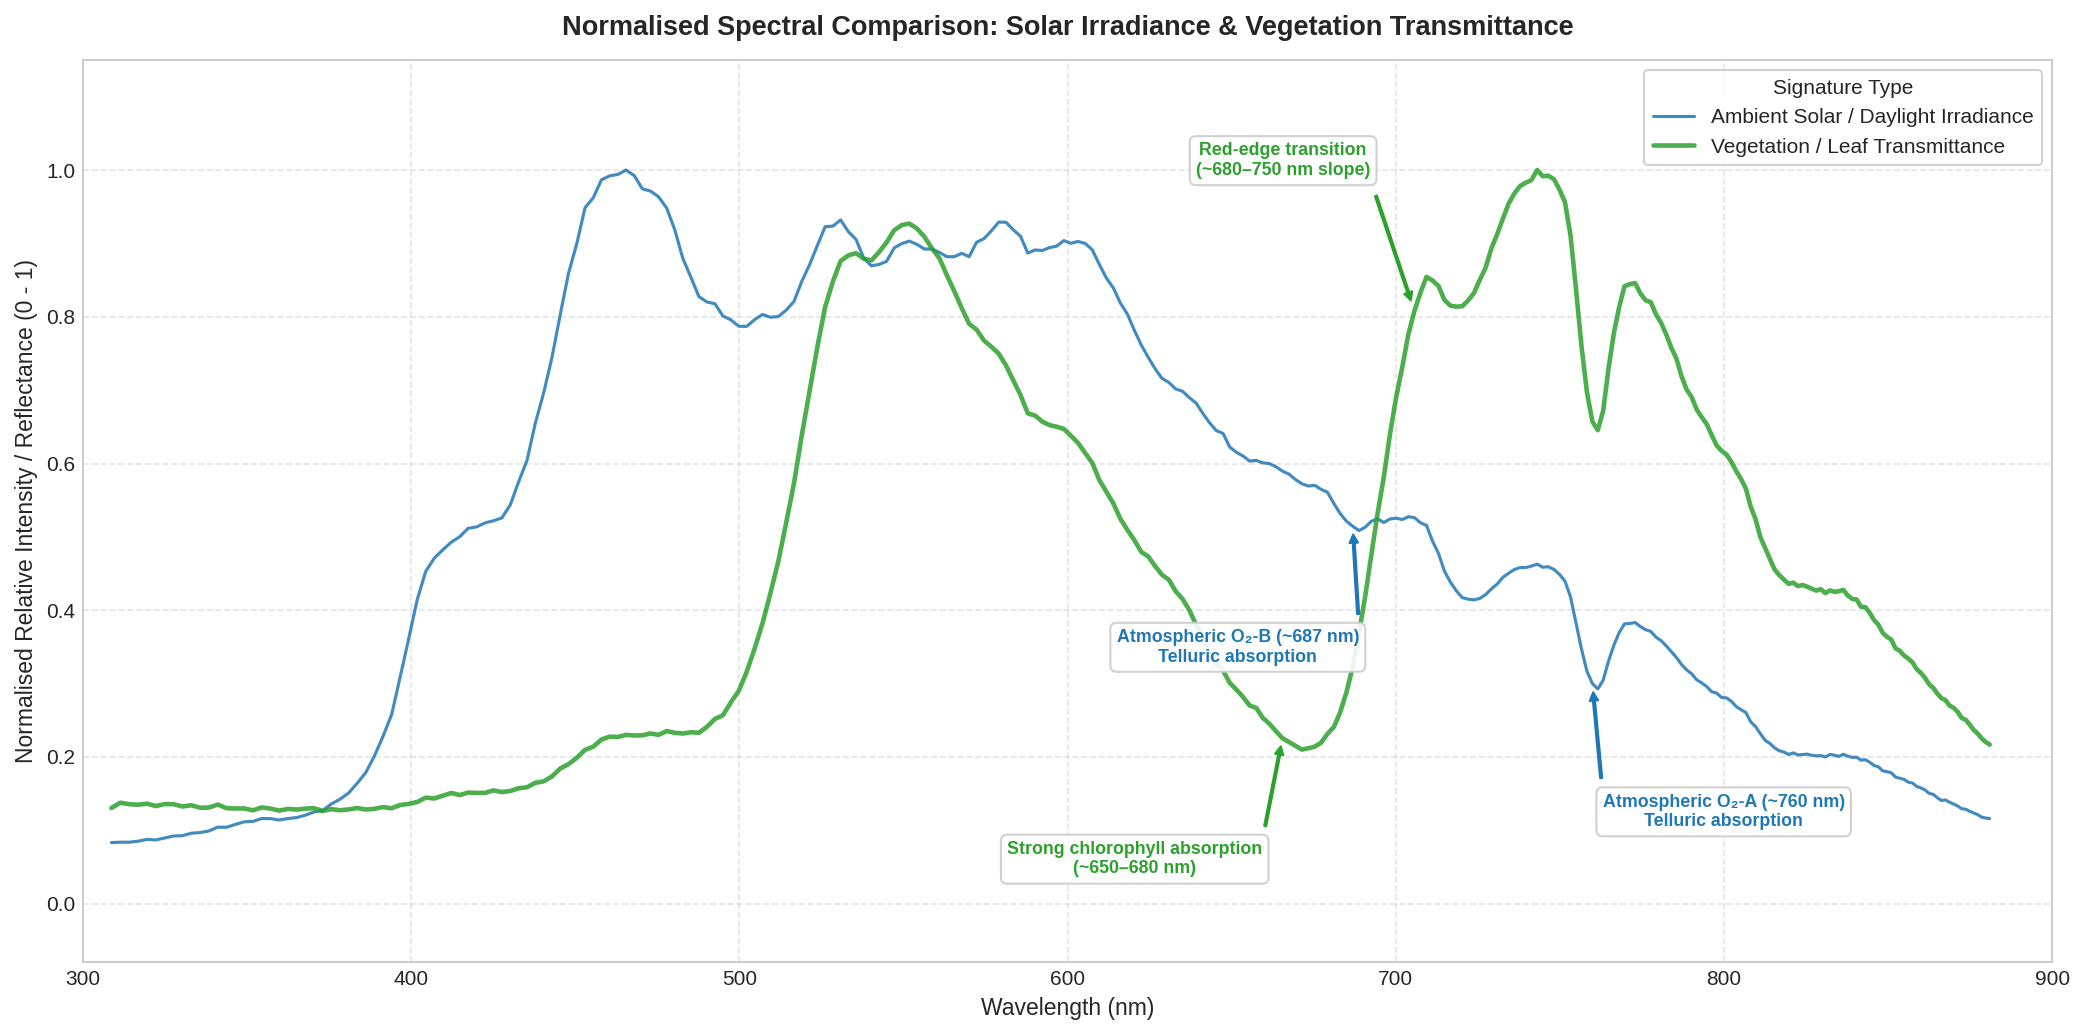

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the DataFrame
df = pd.read_csv('/content/spectra_log.csv')

# Calibration coefficients for Serial 21A02875
A0 = 3.086965198E+02
B1 = 2.718912698E+00
B2 = -1.434471882E-03
B3 = -5.759067943E-06
B4 = 3.250344320E-09
B5 = 1.237572658E-11

def pixel_to_wavelength(pix_rel):
    return (A0 +
            B1 * pix_rel +
            B2 * (pix_rel ** 2) +
            B3 * (pix_rel ** 3) +
            B4 * (pix_rel ** 4) +
            B5 * (pix_rel ** 5))

# Active pixels
active_cols = sorted(
    [col for col in df.columns if re.match(r'^P\d+$', col)],
    key=lambda x: int(x[1:])
)

df_corrected = df.copy()
active_pixel_indices = np.array([int(col[1:]) for col in active_cols], dtype=float)
wavelengths = pixel_to_wavelength(active_pixel_indices)

spectral_columns = active_cols
x_channels = wavelengths

# Plot styling configuration
plt.figure(figsize=(14, 7), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

df_corrected['Comment'] = df_corrected['Comment'].str.strip()
avg_spectra = df_corrected.groupby('Comment')[spectral_columns].mean()

# Updated terminology per expert technical review
plot_styles = {
    'LEAF': {'color': '#2ca02c', 'linewidth': 2.2, 'label': 'Vegetation / Leaf Transmittance'},
    'DAYLIGHT': {'color': '#1f77b4', 'linewidth': 1.5, 'label': 'Ambient Solar / Daylight Irradiance'}
}

# Clean background box style for legibility
bbox_props = dict(boxstyle="round,pad=0.35", fc="white", ec="0.8", alpha=0.9, lw=1)

# Plot each averaged and normalized spectrum
for comment, spectrum_values in avg_spectra.iterrows():
    spectrum_array = spectrum_values.values
    max_intensity = np.max(spectrum_array)
    normalized_spectrum_values = spectrum_array / max_intensity if max_intensity > 0 else spectrum_array

    style = plot_styles.get(comment, {'color': 'gray', 'linewidth': 1.5, 'label': comment})

    plt.plot(x_channels, normalized_spectrum_values,
             label=style['label'], alpha=0.85,
             color=style['color'], linewidth=style['linewidth'])

    # Annotations for Ambient Daylight (Explicitly atmospheric features)
    if comment == 'DAYLIGHT':
        # Oxygen B-band (~687 nm)
        idx_687 = np.abs(x_channels - 687).argmin()
        x_687 = x_channels[idx_687]
        y_687 = normalized_spectrum_values[idx_687]

        plt.annotate('Atmospheric O₂-B (~687 nm)\nTelluric absorption',
                     xy=(x_687, y_687),
                     xytext=(x_687 - 35, y_687 - 0.14),
                     arrowprops=dict(facecolor='#1f77b4', edgecolor='#1f77b4', shrink=0.08, width=1, headwidth=4, headlength=4),
                     fontsize=8.5, fontweight='semibold', color='#1f77b4',
                     bbox=bbox_props, ha='center', va='top')

        # Oxygen A-band (~760 nm)
        idx_760 = np.abs(x_channels - 760).argmin()
        x_760 = x_channels[idx_760]
        y_760 = normalized_spectrum_values[idx_760]

        plt.annotate('Atmospheric O₂-A (~760 nm)\nTelluric absorption',
                     xy=(x_760, y_760),
                     xytext=(x_760 + 40, y_760 - 0.15),
                     arrowprops=dict(facecolor='#1f77b4', edgecolor='#1f77b4', shrink=0.08, width=1, headwidth=4, headlength=4),
                     fontsize=8.5, fontweight='semibold', color='#1f77b4',
                     bbox=bbox_props, ha='center', va='top')

    # Annotations for Vegetation Reflectance
    elif comment == 'LEAF':
        # Strong red chlorophyll absorption (~650-680 nm trough)
        idx_665 = np.abs(x_channels - 665).argmin()
        x_665 = x_channels[idx_665]
        y_665 = normalized_spectrum_values[idx_665]

        plt.annotate('Strong chlorophyll absorption\n(~650–680 nm)',
                     xy=(x_665, y_665),
                     xytext=(x_665 - 45, y_665 - 0.14),
                     arrowprops=dict(facecolor='#2ca02c', edgecolor='#2ca02c', shrink=0.08, width=1, headwidth=4, headlength=4),
                     fontsize=8.5, fontweight='semibold', color='#2ca02c',
                     bbox=bbox_props, ha='center', va='top')

        # Red-edge transition placed accurately on the steep slope (~705 nm)
        idx_red_edge = np.abs(x_channels - 705).argmin()
        x_red_edge = x_channels[idx_red_edge]
        y_red_edge = normalized_spectrum_values[idx_red_edge]

        plt.annotate('Red-edge transition\n(~680–750 nm slope)',
                     xy=(x_red_edge, y_red_edge),
                     xytext=(x_red_edge - 40, y_red_edge + 0.18),
                     arrowprops=dict(facecolor='#2ca02c', edgecolor='#2ca02c', shrink=0.08, width=1, headwidth=4, headlength=4),
                     fontsize=8.5, fontweight='semibold', color='#2ca02c',
                     bbox=bbox_props, ha='center', va='bottom')

# Chart formatting and polish
plt.title('Normalised Spectral Comparison: Solar Irradiance & Vegetation Transmittance', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Wavelength (nm)', fontsize=11)
plt.ylabel('Normalised Relative Intensity / Reflectance (0 - 1)', fontsize=11)
plt.xlim(300, 900)
plt.ylim(-0.08, 1.15)
plt.grid(True, linestyle='--', alpha=0.5)

# Tidy legend placement
plt.legend(title='Signature Type', frameon=True, facecolor='white', framealpha=0.9, loc='upper right')
plt.tight_layout()
plt.show()

In [2]:
min_wavelength = np.min(wavelengths)
max_wavelength = np.max(wavelengths)

print(f"Minimum Wavelength: {min_wavelength:.2f} nm")
print(f"Maximum Wavelength: {max_wavelength:.2f} nm")

Minimum Wavelength: 308.70 nm
Maximum Wavelength: 880.88 nm


When you point a micro-spectrometer like the C12880MA at the open sky or a green leaf, you aren't just capturing messy lines—you are reading a cosmic and biological barcode. The four distinct features on your chart tell a story that bridges quantum mechanics, planetary atmosphere, and plant physiology.

1. The Atmospheric Fingerprints: Oxygen A-Band (760 nm) & B-Band (687 nm)
The Science: As sunlight travels through miles of Earth's atmosphere before hitting your sensor, it passes through molecules of diatomic oxygen ($\text{O}_2$). These molecules have very specific quantum energy states that absorb light at razor-sharp wavelengths. The B-band (687 nm) and the massive A-band (760 nm) are known as telluric absorption lines—dips carved into the solar spectrum entirely by our air.
Why it matters: Seeing these bands with a fingertip-sized spectrometer is remarkable because it proves your wavelength calibration is dead-on. In professional remote sensing, scientists use the depth of the 760 nm Oxygen A-band to calculate cloud top heights, atmospheric pressure, and correct satellite data for atmospheric interference.

2. The Quantum Engine of Life: Chlorophyll Absorption (670 nm)
The Science: If you've ever wondered why plants look green, this dip is the primary culprit. Chlorophyll $a$ and $b$ molecules are nature's ultimate solar panels. Their molecular structure contains conjugated double bonds with delocalized $\pi$-electrons. When a photon hits right around 670 nm (in the red region), its exact energy matches the gap needed to excite an electron to a higher orbital, powering photosynthesis.
Why it matters: This sharp absorption pit is the chemical signature of life. It’s the exact frequency plants rely on to split water molecules and fix carbon dioxide. If a plant is stressed, diseased, or dying, chlorophyll breaks down, and this absorption dip begins to shallow out.

3. The Botanist’s Holy Grail: The Red Edge (680–740 nm)
The Science: Just past the chlorophyll absorption pit lies one of the most dramatic spectacles in optics: The Red Edge. Within a span of just 60 nanometers, plant reflectance goes from near-zero (because the chlorophyll is swallowing the light) to nearly 50–60% reflection. This isn't caused by pigments; it's physics. The internal cellular structure of a leaf (the spongy mesophyll) is transparent to near-infrared light, acting like a maze of tiny mirrors that scatter NIR photons right back out to protect the leaf from overheating.
Why it matters: The position and slope of this edge shift depending on the plant's health. Agronomists and environmental satellites track the Red Edge meticulously to monitor crop stress, nitrogen levels, drought conditions, and seasonal forest changes long before the human eye can spot a yellowing leaf.